In [29]:
import os
import json
import matplotlib.pyplot as plt


In [30]:
def load_itl_by_rate(path):
    with open(path) as f:
        data = json.load(f)
    rows = []
    for b in data["benchmarks"]:
        rate = b["config"]["strategy"]["rate"]
        itl = b["metrics"]["inter_token_latency_ms"]
        out_tok_per_sec = b["metrics"]["output_tokens_per_second"]["successful"]["mean"]
        total = itl["successful"]
        rows.append({
            "rate": rate,
            "mean": total["mean"],
            "p50": total["percentiles"]["p50"],
            "p95": total["percentiles"]["p95"],
            "output_tokens_per_sec": out_tok_per_sec,
        })
    return sorted(rows, key=lambda x: x["rate"])


In [34]:
RESULT_DIR = "results/20260304-041200"


In [35]:
baseline = load_itl_by_rate(os.path.join(RESULT_DIR, "result-baseline.json"))
suffix = load_itl_by_rate(os.path.join(RESULT_DIR, "result-suffix_decoding.json"))
ngram = load_itl_by_rate(os.path.join(RESULT_DIR, "result-ngram_k4.json"))

rates_b = [x["rate"] for x in baseline]
rates_s = [x["rate"] for x in suffix]
rates_n = [x["rate"] for x in ngram]
print("Baseline rates:", rates_b)
print("Suffix rates:", rates_s)
print("Ngram rates:", rates_n)


Baseline rates: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
Suffix rates: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
Ngram rates: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]


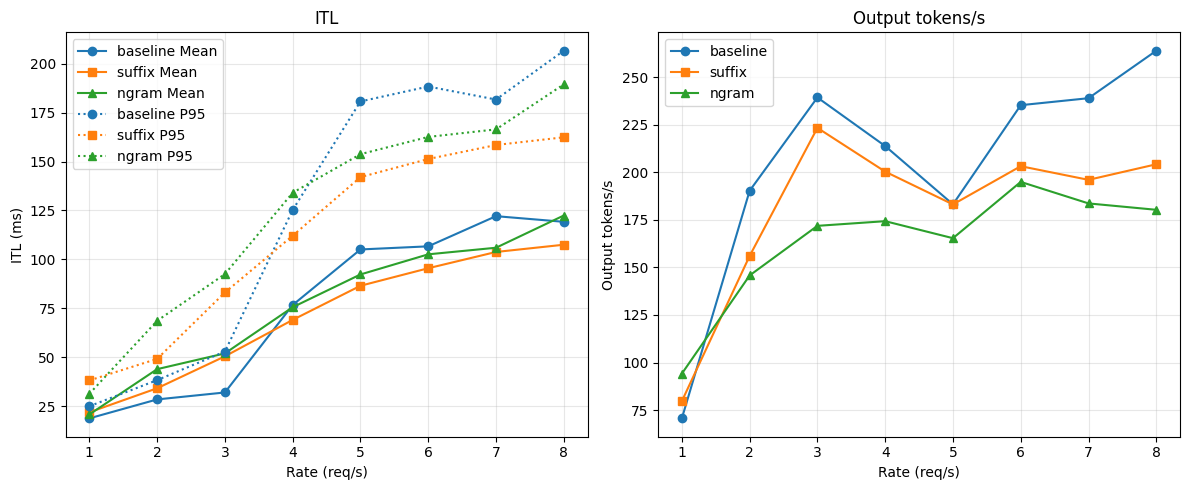

In [36]:
fig, (ax_itl, ax_rps) = plt.subplots(1, 2, figsize=(12, 5))

# Left: ITL (color: baseline vs suffix, line style: mean / p50 / p95)
metrics = [
    ("mean", "Mean", "-"),
    # ("p50", "P50", "--"),
    ("p95", "P95", ":")
]
for key, label, ls in metrics:
    ax_itl.plot(rates_b, [x[key] for x in baseline], "o" + ls, label=f"baseline {label}", color="C0")
    ax_itl.plot(rates_s, [x[key] for x in suffix], "s" + ls, label=f"suffix {label}", color="C1")
    ax_itl.plot(rates_n, [x[key] for x in ngram], "^" + ls, label=f"ngram {label}", color="C2")
ax_itl.set_xlabel("Rate (req/s)")
ax_itl.set_ylabel("ITL (ms)")
ax_itl.set_title("ITL")
ax_itl.legend()
ax_itl.grid(True, alpha=0.3)

# Right: output tokens/s (baseline vs suffix vs ngram)
ax_rps.plot(rates_b, [x["output_tokens_per_sec"] for x in baseline], "o-", label="baseline", color="C0")
ax_rps.plot(rates_s, [x["output_tokens_per_sec"] for x in suffix], "s-", label="suffix", color="C1")
ax_rps.plot(rates_n, [x["output_tokens_per_sec"] for x in ngram], "^-", label="ngram", color="C2")
ax_rps.set_xlabel("Rate (req/s)")
ax_rps.set_ylabel("Output tokens/s")
ax_rps.set_title("Output tokens/s")
ax_rps.legend()
ax_rps.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


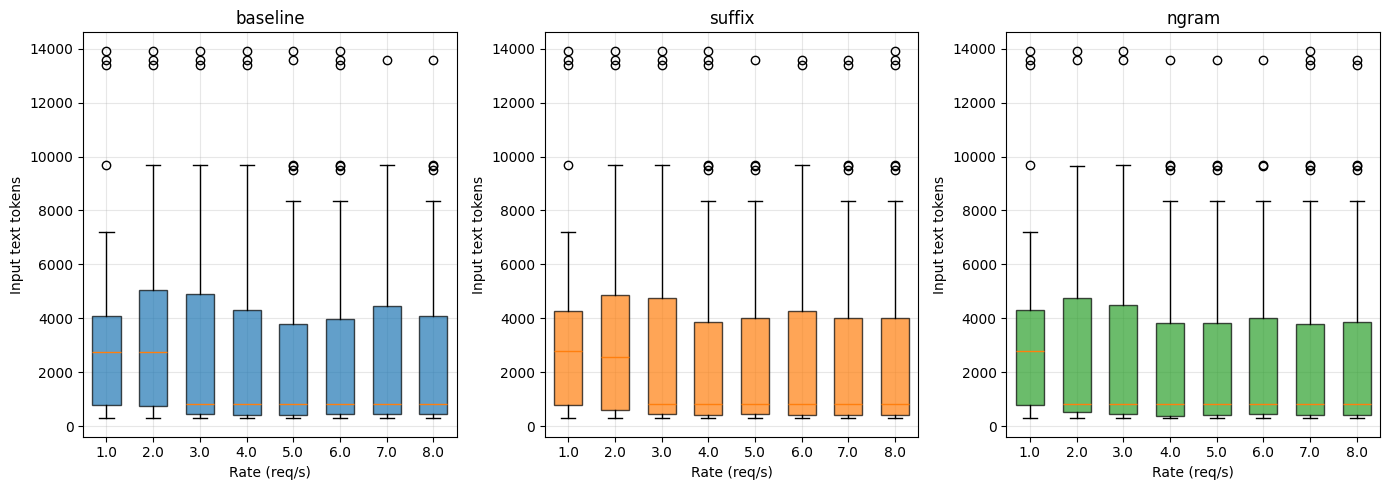

In [37]:
def load_input_tokens_by_benchmark(path):
    """Return list of (rate, list of text_tokens) per benchmark."""
    with open(path) as f:
        data = json.load(f)
    out = []
    for b in data["benchmarks"]:
        rate = b["config"]["strategy"]["rate"]
        tokens = []
        for req in b["requests"].get("successful", []):
            tt = req.get("input_metrics", {}).get("text_tokens")
            if tt is not None:
                tokens.append(tt)
        out.append((rate, tokens))
    return sorted(out, key=lambda x: x[0])

# Load for all three configs
baseline_tokens = load_input_tokens_by_benchmark(os.path.join(RESULT_DIR, "result-baseline.json"))
suffix_tokens = load_input_tokens_by_benchmark(os.path.join(RESULT_DIR, "result-suffix_decoding.json"))
ngram_tokens = load_input_tokens_by_benchmark(os.path.join(RESULT_DIR, "result-ngram_k4.json"))

# Plot: distribution of input text_tokens per benchmark (by rate)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
configs = [
    ("baseline", baseline_tokens, "C0"),
    ("suffix", suffix_tokens, "C1"),
    ("ngram", ngram_tokens, "C2"),
]
for ax, (name, data, color) in zip(axes, configs):
    rates = [r for r, _ in data]
    boxes = [toks for _, toks in data]
    bp = ax.boxplot(boxes, positions=range(len(rates)), widths=0.6, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels([str(r) for r in rates])
    ax.set_xlabel("Rate (req/s)")
    ax.set_ylabel("Input text tokens")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
